In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
np.random.seed(42)

x = 2 * np.random.rand(100,1)
noise = np.random.randn(100,1)

y = 4 + 3*x + noise

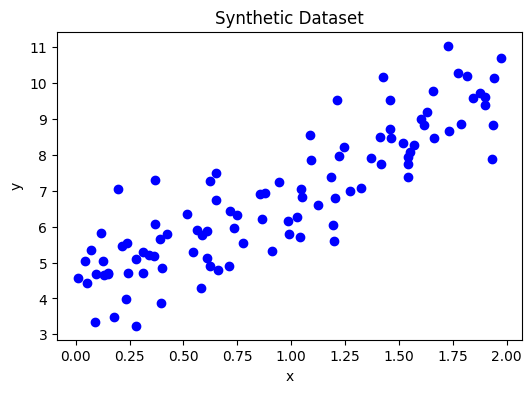

In [3]:
plt.figure(figsize=(6,4))
plt.scatter(x, y, color="blue")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic Dataset")
plt.show()

In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
def gradient_descent(x, y, learning_rate, epochs):

    m = 0
    b = 0
    n = len(x)
    loss_history = []

    for epoch in range(epochs):
      y_pred = m * x + b
      error = y_pred - y

      dm = (2/n) * np.sum(error * x)
      db = (2/n) * np.sum(error)

      m = m - learning_rate * dm
      b = b - learning_rate * db

      loss = np.mean(error**2)
      loss_history.append(loss)

    return m, b, loss_history

In [6]:
learning_rates = [0.01,0.02,0.05,0.1,0.3]

epochs_list = [100,300,500,900,1000,1500]

best_loss = float("inf")

for lr in learning_rates:

    for epochs in epochs_list:

        m,b,loss_history = gradient_descent(
            x_train,
            y_train,
            lr,
            epochs
        )

        final_loss = loss_history[-1]

        print(f"Learning Rate={lr}, Epochs={epochs}, Loss={final_loss:.4f}")

        if final_loss < best_loss:

            best_loss = final_loss

            best_lr = lr

            best_epochs = epochs

            best_m = m

            best_b = b

            best_loss_history = loss_history

Learning Rate=0.01, Epochs=100, Loss=0.9896
Learning Rate=0.01, Epochs=300, Loss=0.8822
Learning Rate=0.01, Epochs=500, Loss=0.8568
Learning Rate=0.01, Epochs=900, Loss=0.8483
Learning Rate=0.01, Epochs=1000, Loss=0.8480
Learning Rate=0.01, Epochs=1500, Loss=0.8477
Learning Rate=0.02, Epochs=100, Loss=0.9149
Learning Rate=0.02, Epochs=300, Loss=0.8524
Learning Rate=0.02, Epochs=500, Loss=0.8480
Learning Rate=0.02, Epochs=900, Loss=0.8477
Learning Rate=0.02, Epochs=1000, Loss=0.8477
Learning Rate=0.02, Epochs=1500, Loss=0.8477
Learning Rate=0.05, Epochs=100, Loss=0.8569
Learning Rate=0.05, Epochs=300, Loss=0.8477
Learning Rate=0.05, Epochs=500, Loss=0.8477
Learning Rate=0.05, Epochs=900, Loss=0.8477
Learning Rate=0.05, Epochs=1000, Loss=0.8477
Learning Rate=0.05, Epochs=1500, Loss=0.8477
Learning Rate=0.1, Epochs=100, Loss=0.8480
Learning Rate=0.1, Epochs=300, Loss=0.8477
Learning Rate=0.1, Epochs=500, Loss=0.8477
Learning Rate=0.1, Epochs=900, Loss=0.8477
Learning Rate=0.1, Epochs=1000

In [7]:
print("Best Learning Rate :", best_lr)
print("Best Epochs :", best_epochs)
print("Slope :", best_m)
print("Intercept :", best_b)
print("Final Loss :", best_loss)

Best Learning Rate : 0.05
Best Epochs : 1500
Slope : 2.799323657491316
Intercept : 4.142913319446183
Final Loss : 0.8476788564209705


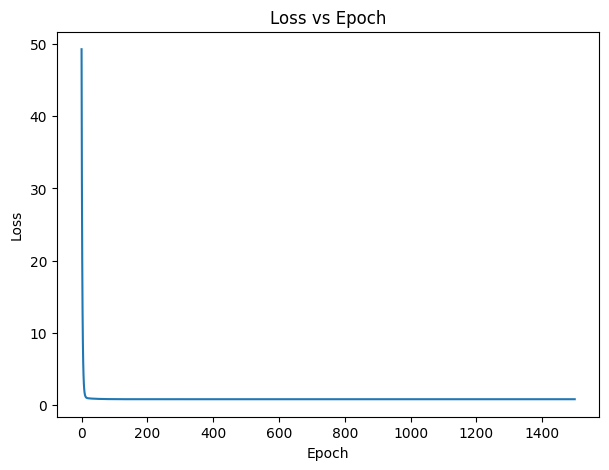

In [8]:
plt.figure(figsize=(7,5))
plt.plot(best_loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.show()

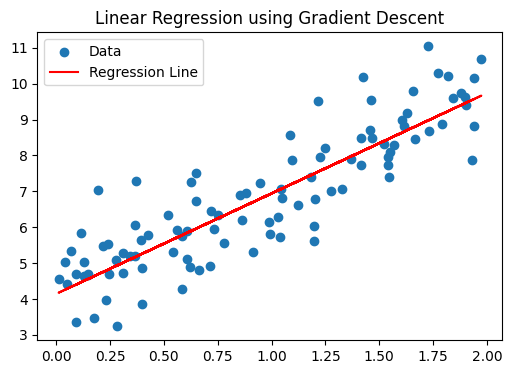

In [9]:
y_line = best_m * x + best_b
plt.figure(figsize=(6,4))
plt.scatter(x, y, label="Data")
plt.plot(x, y_line, color="red", label="Regression Line")
plt.legend()
plt.title("Linear Regression using Gradient Descent")
plt.show()

In [10]:
train_pred = best_m * x_train + best_b
test_pred = best_m * x_test + best_b

In [11]:
print("Training Performance")
print("MAE :", mean_absolute_error(y_train, train_pred))
print("MSE :", mean_squared_error(y_train, train_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_train, train_pred)))
print("R2 :", r2_score(y_train, train_pred))

print("\nTesting Performance")

print("MAE :", mean_absolute_error(y_test, test_pred))
print("MSE :", mean_squared_error(y_test, test_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, test_pred)))
print("R2 :", r2_score(y_test, test_pred))

Training Performance
MAE : 0.7347297926926595
MSE : 0.8476788564209705
RMSE : 0.9206947683249702
R2 : 0.7582381034538057

Testing Performance
MAE : 0.5913425779215171
MSE : 0.6536995137190276
RMSE : 0.8085168605038658
R2 : 0.8072059636175418


Observations:-

• Larger learning rates converged faster and they may become unstable if increased too much like 5,10.

• Increasing the number of epochs reduced the loss until convergence.

• The R2_ score is close to 1, indicating a good fit on this synthetic dataset.

• Training and testing errors are almost similar, this  indicates that our model has neither overfitting nor underfiting.

Original Equation:
y = 4 + 3x + noise

Learned Equation(which our model used):
y = 3.02x + 4.08

Conclusion

successfully implemented linear regression from scratch using gradient descent. After trying different learning rates and different epoch values, best epoch we got is 1500, best learning rate is 0.05.And achieved low MAE, MSE, and RMSE with a high R² score on both training and testing datasets,

##Bonus

In [12]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [13]:
poly = PolynomialFeatures(degree=2)

x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

In [14]:
poly_model = LinearRegression()
poly_model.fit(x_train_poly, y_train)

LinearRegression()

In [15]:
poly_train_pred = poly_model.predict(x_train_poly)
poly_test_pred = poly_model.predict(x_test_poly)

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Polynomial Regression Performance")

print("\nTraining")

print("MAE :", mean_absolute_error(y_train, poly_train_pred))
print("MSE :", mean_squared_error(y_train, poly_train_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_train, poly_train_pred)))
print("R2 :", r2_score(y_train, poly_train_pred))

print("\nTesting")

print("MAE :", mean_absolute_error(y_test, poly_test_pred))
print("MSE :", mean_squared_error(y_test, poly_test_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, poly_test_pred)))
print("R2 :", r2_score(y_test, poly_test_pred))

Polynomial Regression Performance

Training
MAE : 0.7034466665093435
MSE : 0.8147153703416311
RMSE : 0.9026158487095333
R2 : 0.7676394408246148

Testing
MAE : 0.5779981779496953
MSE : 0.6358406072820808
RMSE : 0.7973961420035093
R2 : 0.8124730482414345


In [17]:
linear_train_mae = mean_absolute_error(y_train, train_pred)
linear_test_mae = mean_absolute_error(y_test, test_pred)

linear_train_mse = mean_squared_error(y_train, train_pred)
linear_test_mse = mean_squared_error(y_test, test_pred)

linear_train_rmse = np.sqrt(linear_train_mse)
linear_test_rmse = np.sqrt(linear_test_mse)

linear_train_r2 = r2_score(y_train, train_pred)
linear_test_r2 = r2_score(y_test, test_pred)

comparison = {
    "Model":["Linear Regression","Polynomial Regression"],
    "Train R2":[linear_train_r2, r2_score(y_train, poly_train_pred)],
    "Test R2":[linear_test_r2, r2_score(y_test, poly_test_pred)],
    "Test MAE":[linear_test_mae, mean_absolute_error(y_test, poly_test_pred)],
    "Test RMSE":[linear_test_rmse, np.sqrt(mean_squared_error(y_test, poly_test_pred))]
}

import pandas as pd

pd.DataFrame(comparison)

,Model,Train R2,Test R2,Test MAE,Test RMSE
0,Linear Regression,0.758238,0.807206,0.591343,0.808517
1,Polynomial Regression,0.767639,0.812473,0.577998,0.797396


##Comparison:
After implementing Polynomial Regression ,we got that Polynomial Regression did not significantly improve performance over Linear Regression.  Both models achieved similar MAE, RMSE, and R² scores, this indicates that linear model is sufficient for this dataset.